# Bootcamp Class Marketing Campaign

## Background

As a Data Analyst, I explore the effectiveness of digital campaigns for sales Bootcamp Class as a key driver of company revenue growth through various advertising channels. This analysis focuses on evaluating social media budget allocations to identify the most responsive audience segments and the channels that deliver the most consistent monthly performance.

## Goal

Describe the characteristics of the Data

## Variable Description

- CampaignID : Campaign Identity
- Channel : The platform where the ads run.
- AudienceType : Type of targeting audience
- AdBudgetK : The advertising budget spent.
- CTR : Click Through Rate
- ConversionRate : Conversion Rate
- Month : Month
- RevenueK : The income generated by generated

## Key Objective

1. Analyzing the Relationship Between Advertising Budget and Revenue
2. Identifying the Best Advertising Channels
3. Understanding Audience Profiles
4. Analyzing Monthly Campaign & Revenue Trends
5. Comparing Revenue Performance across Dimensions

In [1]:
# import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from statistics import mode
from IPython.display import Image
sns.set(style="darkgrid")

In [2]:
# read dataset
campaign = pd.read_excel('campaign_dataset_5000.xlsx') 

In [3]:
campaign.head()

,CampaignID,Channel,AudienceType,AdBudgetK,CTR,ConversionRate,Month,RevenueK
0,1,Instagram Ads,Gen Z,20,4.56,1.16,Jan,112.21
1,1,Instagram Ads,Interest-Based,15,3.96,2.00,Feb,103.92
2,1,Instagram Ads,Interest-Based,21,4.46,2.49,Mar,228.56
3,2,Google Ads,Broad,16,3.98,1.37,Apr,73.69
4,2,Google Ads,Lookalike,23,3.09,2.18,May,111.36


In [4]:
campaign['AudienceType'].unique()

array(['Gen Z', 'Interest-Based', 'Broad', 'Lookalike', 'Retargeting'],
      dtype=object)

In [5]:
campaign.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CampaignID      5000 non-null   int64  
 1   Channel         5000 non-null   object 
 2   AudienceType    5000 non-null   object 
 3   AdBudgetK       5000 non-null   int64  
 4   CTR             5000 non-null   float64
 5   ConversionRate  5000 non-null   float64
 6   Month           5000 non-null   object 
 7   RevenueK        5000 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 312.6+ KB


- There is no missing value in this data
- Dataset has 8 column and 5000 rows

In [6]:
campaign['Channel'].unique()

array(['Instagram Ads', 'Google Ads', 'Facebook Ads', 'TikTok Ads'],
      dtype=object)

To identify the number of advertising channels used.

### Numerical Variable

We will explore the numerical variables (AdBudgetK, Revenue) in the data.

In [7]:
# Descriptive Statistic
campaign.describe()

,CampaignID,AdBudgetK,CTR,ConversionRate,RevenueK
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.490600,14.042200,5.829684,2.325588,192.097354
std,1.110747,4.639776,2.954297,1.365651,166.033129
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,11.000000,3.790000,1.410000,84.775000
50%,2.000000,14.000000,5.270000,2.150000,148.290000
75%,3.000000,17.000000,7.260000,3.030000,250.192500
max,4.000000,24.000000,21.460000,13.900000,1814.690000


The average revenue generated from all advertising channels during 2024 is $192.09K

In [8]:
campaign.loc[campaign['RevenueK']==max(campaign['RevenueK'])]

,CampaignID,Channel,AudienceType,AdBudgetK,CTR,ConversionRate,Month,RevenueK
1343,1,Instagram Ads,Lookalike,21,8.78,13.9,Dec,1814.69


According to the data, it has the highest revenue through the Instagram Ads channel with a Lookalike Audience of $1814.69K

In [9]:
campaign.loc[campaign['RevenueK']==min(campaign['RevenueK'])]

,CampaignID,Channel,AudienceType,AdBudgetK,CTR,ConversionRate,Month,RevenueK
23,4,TikTok Ads,Interest-Based,0,0.0,0.0,Dec,0.0
31,2,Google Ads,Broad,0,0.0,0.0,Aug,0.0
50,4,TikTok Ads,Gen Z,0,0.0,0.0,Mar,0.0
155,3,Facebook Ads,Interest-Based,0,0.0,0.0,Dec,0.0
258,2,Google Ads,Broad,0,0.0,0.0,Jul,0.0
...,...,...,...,...,...,...,...,...
4745,1,Instagram Ads,Lookalike,0,0.0,0.0,Jun,0.0
4759,4,TikTok Ads,Retargeting,0,0.0,0.0,Aug,0.0
4761,2,Google Ads,Interest-Based,0,0.0,0.0,Oct,0.0
4955,3,Facebook Ads,Retargeting,0,0.0,0.0,Dec,0.0


Approximately 105 channels generated no revenue. Based on that descriptive analysis, this was due to the lack of campaign budget allocation during those months.

In [10]:
campaign.loc[campaign['AdBudgetK']==max(campaign['AdBudgetK'])].describe()

,CampaignID,AdBudgetK,CTR,ConversionRate,RevenueK
count,73.0,73.0,73.000000,73.00000,73.000000
mean,2.0,24.0,4.076164,2.97589,281.365890
std,0.0,0.0,1.204089,1.52856,189.612983
min,2.0,24.0,1.840000,0.13000,7.280000
25%,2.0,24.0,3.180000,2.17000,153.270000
50%,2.0,24.0,3.920000,2.84000,245.560000
75%,2.0,24.0,5.040000,3.76000,350.690000
max,2.0,24.0,7.690000,7.47000,1014.750000


In [11]:
campaign.loc[campaign['AdBudgetK']==min(campaign['AdBudgetK'])].describe()

,CampaignID,AdBudgetK,CTR,ConversionRate,RevenueK
count,105.000000,105.0,105.0,105.0,105.0
mean,2.447619,0.0,0.0,0.0,0.0
std,1.126439,0.0,0.0,0.0,0.0
min,1.000000,0.0,0.0,0.0,0.0
25%,1.000000,0.0,0.0,0.0,0.0
50%,3.000000,0.0,0.0,0.0,0.0
75%,3.000000,0.0,0.0,0.0,0.0
max,4.000000,0.0,0.0,0.0,0.0


**Characteristic of data that has the maximum AdBudget**

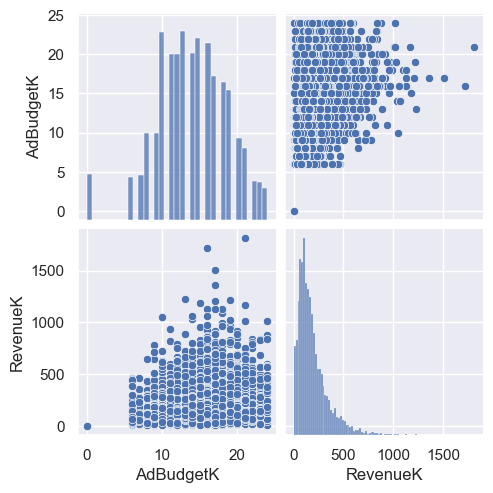

In [12]:
#get histogram and scatterplot between numeric variables
sns.pairplot(campaign[['AdBudgetK','RevenueK']])
plt.show()

An increase in AdBudget has the potential to increase income, but the relationship is not linear. There are times when a large AdBudget generates low income.

In [13]:
# correlation between numeric variables
campaign[['AdBudgetK', 'RevenueK']].corr()

,AdBudgetK,RevenueK
AdBudgetK,1.000000,0.321172
RevenueK,0.321172,1.000000


The correlation between Adbudget and revenue is 0.32. This is a weak positive correlation. We can say that advertising does contribute positively to revenue, but its contribution is not dominant, as there are other factors that impact it.

<Axes: xlabel='AdBudgetK', ylabel='AVG of Revenue'>

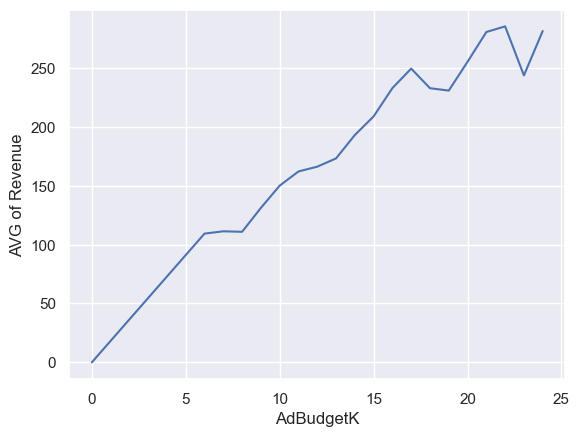

In [14]:
# plot avg revenue
campaign_as = campaign.groupby('AdBudgetK')['RevenueK'].mean()
plt.ylabel('AVG of Revenue')
campaign_as.plot()

In general, the graph moves to the top right. This means that the larger the allocated AdBudget, the higher the revenue generated. However, there is a decrease in revenue when the budget is increased. This can indicate the efficiency of the ad budget for a particular ads.

## Categorical Variables

**1. Channel**

In [15]:
campaign.groupby(['Channel']).size()

Channel
Facebook Ads     1270
Google Ads       1271
Instagram Ads    1245
TikTok Ads       1214
dtype: int64

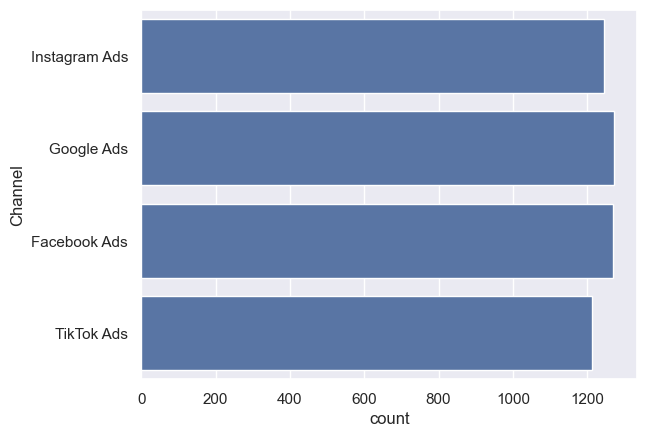

In [16]:
sns.countplot(y='Channel', data = campaign)
plt.show()

There is no difference in class sales between the four channels, but TikTokAds is lower than the other three channels.

In [17]:
campaign.head()

,CampaignID,Channel,AudienceType,AdBudgetK,CTR,ConversionRate,Month,RevenueK
0,1,Instagram Ads,Gen Z,20,4.56,1.16,Jan,112.21
1,1,Instagram Ads,Interest-Based,15,3.96,2.00,Feb,103.92
2,1,Instagram Ads,Interest-Based,21,4.46,2.49,Mar,228.56
3,2,Google Ads,Broad,16,3.98,1.37,Apr,73.69
4,2,Google Ads,Lookalike,23,3.09,2.18,May,111.36


**2. AudienceType**

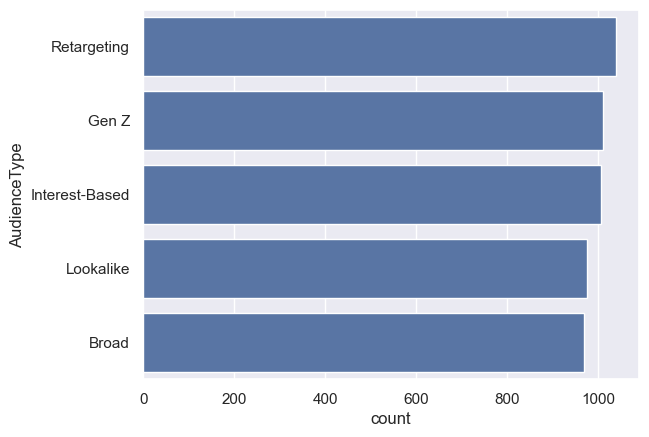

In [18]:
# Sort of AudienceType from the largest to the smallest number.
order_list = campaign['AudienceType'].value_counts().index

sns.countplot(y='AudienceType', data=campaign, order=order_list)
plt.show()

In [19]:
mode(campaign['AudienceType'])

'Retargeting'

Based on the identification of audience types, the audience has a balanced distribution across the five main categories, with the largest is *regerting* and the smallest is *broad*.

**3. Month**

In [20]:
campaign.groupby(['Month']).size()

Month
Apr    417
Aug    417
Dec    416
Feb    417
Jan    417
Jul    417
Jun    417
Mar    417
May    417
Nov    416
Oct    416
Sep    416
dtype: int64

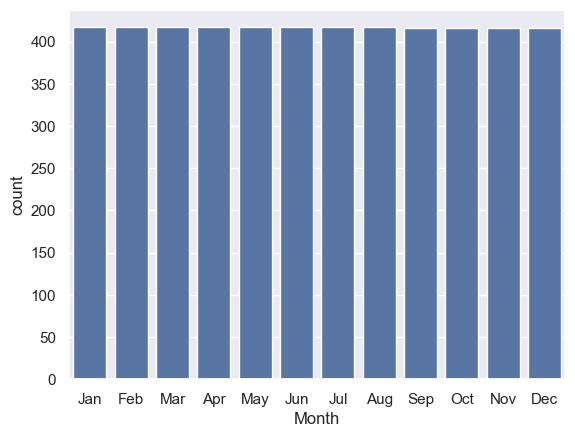

In [21]:
sns.countplot(x='Month', data = campaign)
plt.show()

in this campaign there is a balanced sales every month

In [22]:
campaign.head()

,CampaignID,Channel,AudienceType,AdBudgetK,CTR,ConversionRate,Month,RevenueK
0,1,Instagram Ads,Gen Z,20,4.56,1.16,Jan,112.21
1,1,Instagram Ads,Interest-Based,15,3.96,2.00,Feb,103.92
2,1,Instagram Ads,Interest-Based,21,4.46,2.49,Mar,228.56
3,2,Google Ads,Broad,16,3.98,1.37,Apr,73.69
4,2,Google Ads,Lookalike,23,3.09,2.18,May,111.36


**4. AudienceType vs Channel**

In [23]:
campaign.groupby(['AudienceType', 'Channel']).size().unstack()*(100/len(campaign))

Channel,Facebook Ads,Google Ads,Instagram Ads,TikTok Ads
AudienceType,,,,
Broad,4.72,5.24,4.90,4.52
Gen Z,5.22,4.82,5.30,4.86
Interest-Based,4.98,5.38,4.88,4.90
Lookalike,4.96,4.58,4.98,5.00
Retargeting,5.52,5.40,4.84,5.00


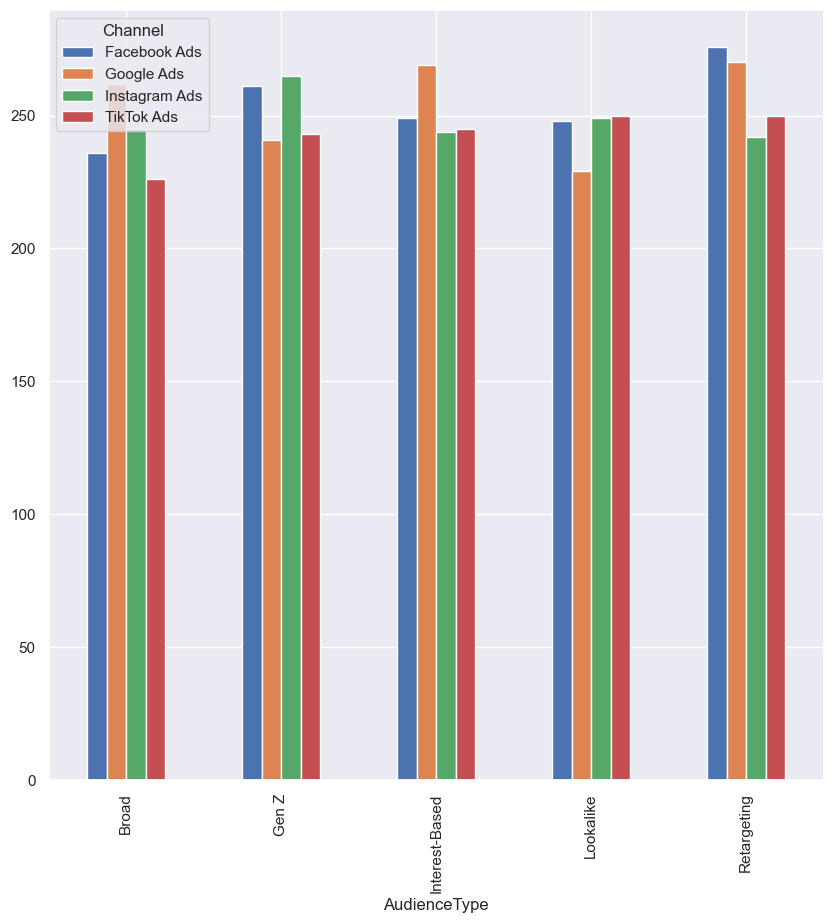

In [24]:
fig, ax = plt.subplots(figsize=(10,10))
campaign.groupby(['AudienceType', 'Channel']).size().unstack().plot(kind='bar', ax=ax)
plt.show()

- Retargeting strategies on Facebook and Google platforms are the highest revenue contributors, while Broad audiences on TikTok require evaluation due to their lowest performance. 
- Instagram remains the most consistent top choice for targeting Gen Z.

In [25]:
# 1. Tentukan urutan bulan yang benar
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# 2. Ubah kolom Month menjadi kategori dengan urutan di atas
campaign['Month'] = pd.Categorical(campaign['Month'], categories=month_order, ordered=True)


In [26]:
campaign.groupby(['Month', 'Channel']).size().unstack()

C:\Users\HP Victus\AppData\Local\Temp\ipykernel_13756\817562511.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign.groupby(['Month', 'Channel']).size().unstack()


Channel,Facebook Ads,Google Ads,Instagram Ads,TikTok Ads
Month,,,,
Jan,110,103,103,101
Feb,98,106,116,97
Mar,107,103,92,115
Apr,83,110,104,120
May,112,107,100,98
Jun,105,111,102,99
Jul,115,104,100,98
Aug,107,110,102,98
Sep,125,92,106,93


C:\Users\HP Victus\AppData\Local\Temp\ipykernel_13756\3824813814.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_plot = campaign.groupby(['Month', 'Channel']).size().unstack()


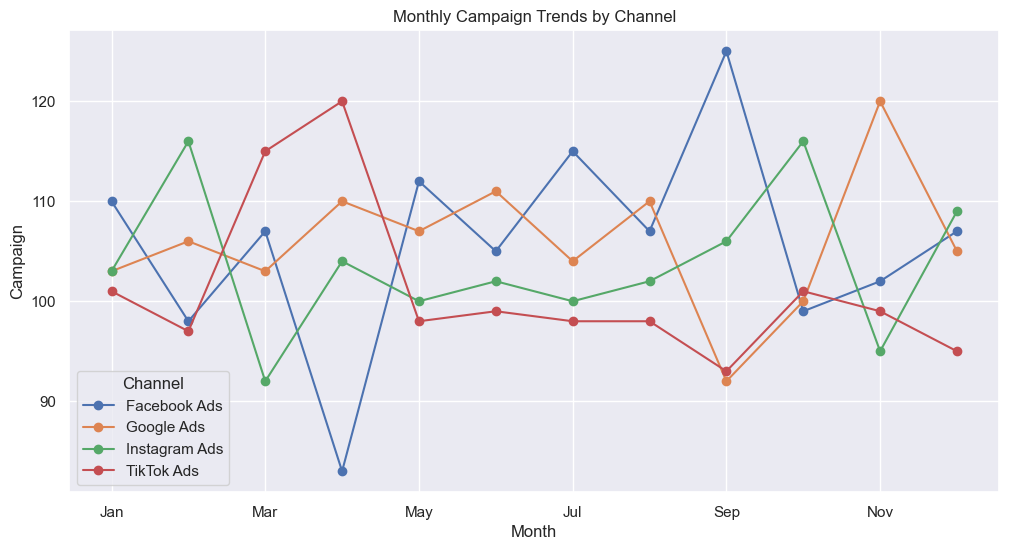

In [27]:
# Ubah struktur agar 'Month' jadi index untuk sumbu X
campaign_plot = campaign.groupby(['Month', 'Channel']).size().unstack()

# Plotting
campaign_plot.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Monthly Campaign Trends by Channel')
plt.ylabel('Campaign')
plt.show()

- Facebook Ads showed the most extreme fluctuations. It reached its lowest point in April (83 campaigns), but then surged sharply to its highest in September (125 campaigns).
- TikTok Ads seemed very active at the beginning of the year (March-April), but the intensity continued to decline consistently until the end of the year (reaching 95 in December)

### Categorical and Numerical Variables

**1. Channel vs AdBudgetK**

In [28]:
campaign.groupby(['Channel']).agg({'AdBudgetK':['count','mean','median','sum']})

AdBudgetK                         
                  count       mean median    sum
Channel                                         
Facebook Ads       1270  13.310236   13.0  16904
Google Ads         1271  16.578285   17.0  21071
Instagram Ads      1245  15.038554   15.0  18723
TikTok Ads         1214  11.130972   11.0  13513

- Google Ads has the highest Ad budget for campaign
- TikTok Ads have the lowest budget

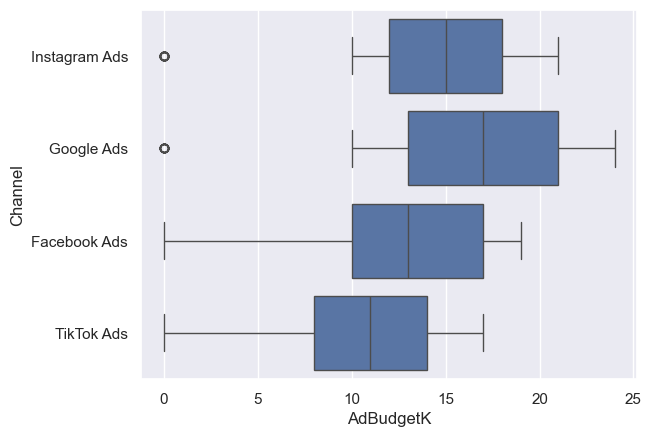

In [29]:
sns.boxplot(x='AdBudgetK', y='Channel', data=campaign)
plt.show()

- The Instagram Ads and Google Ads channels have no budget allocated. This appears to be the cause of the outliers observed in the boxplot.

**2. Channel vs RevenueK**

In [30]:
campaign.groupby(['Channel']).agg({'RevenueK':['count','mean','median','sum']})

RevenueK                               
                 count        mean  median        sum
Channel                                              
Facebook Ads      1270  187.686803  140.21  238362.24
Google Ads        1271  197.886876  154.25  251514.22
Instagram Ads     1245  204.981807  159.05  255202.35
TikTok Ads        1214  177.436540  134.12  215407.96

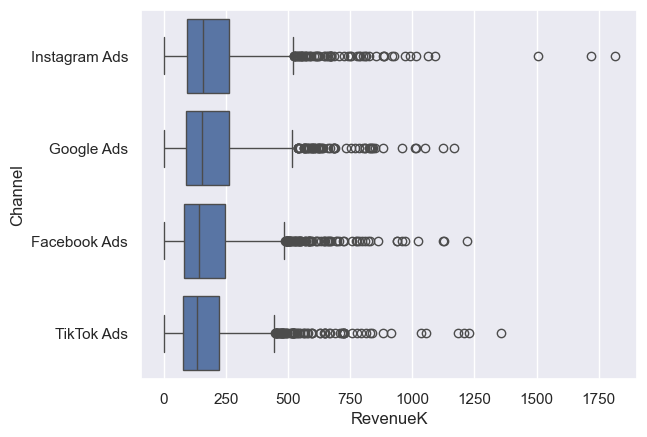

In [31]:
sns.boxplot(x='RevenueK', y='Channel', data=campaign)
plt.show()

- Instagram Ads generate the highest revenue on average.
- TikTok Ads generate the lowest revenue


**3. Month vs RevenueK**

In [32]:
campaign.groupby(['Month']).agg({'RevenueK':['count','mean','median','sum']})

C:\Users\HP Victus\AppData\Local\Temp\ipykernel_13756\4293332427.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign.groupby(['Month']).agg({'RevenueK':['count','mean','median','sum']})


RevenueK                               
         count        mean  median        sum
Month                                        
Jan        417   97.165635   85.60   40518.07
Feb        417  115.590384  103.36   48201.19
Mar        417  159.504484  142.63   66513.37
Apr        417  168.488297  144.35   70259.62
May        417  194.477290  164.59   81097.03
Jun        417  211.556595  177.41   88219.10
Jul        417  148.056571  125.85   61739.59
Aug        417  140.182494  112.54   58456.10
Sep        416  168.480601  138.93   70087.93
Oct        416  212.314760  184.64   88322.94
Nov        416  322.634904  259.51  134216.12
Dec        416  367.441611  341.63  152855.71

C:\Users\HP Victus\AppData\Local\Temp\ipykernel_13756\3027384012.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_we = campaign.groupby('Month')['RevenueK'].mean()


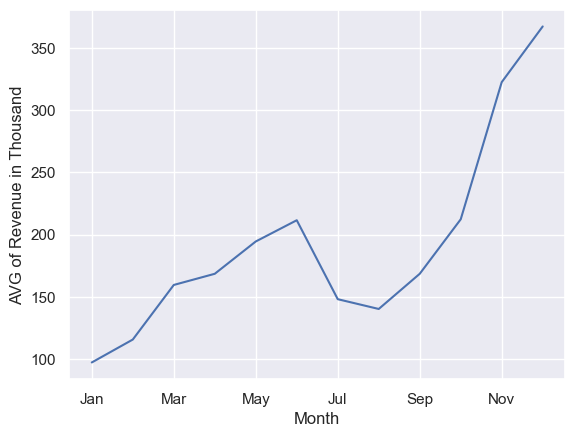

In [33]:
campaign_we = campaign.groupby('Month')['RevenueK'].mean()
campaign_we.plot()
plt.ylabel('AVG of Revenue in Thousand')
plt.show()

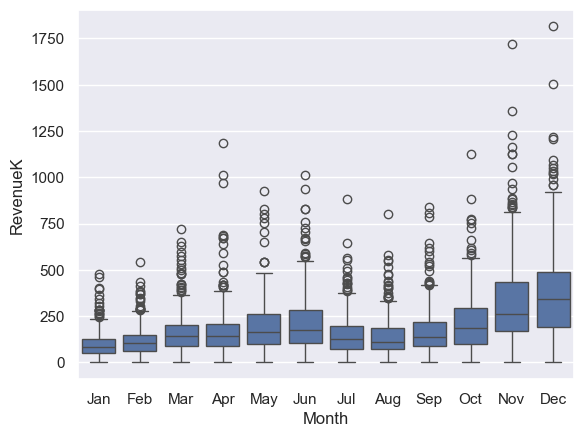

In [34]:
sns.boxplot(x='Month', y='RevenueK', data=campaign)
plt.show()

- In general, average revenue shows a significant increasing trend from the beginning of the year to the end of the year.
- There was a significant increase in November and December
- At the end of the year, performance across ad campaigns became increasingly variable, indicating a successful end-of-year promotional effect for certain campaigns.


**4. Channel vs RevenueK vs AudienceType**

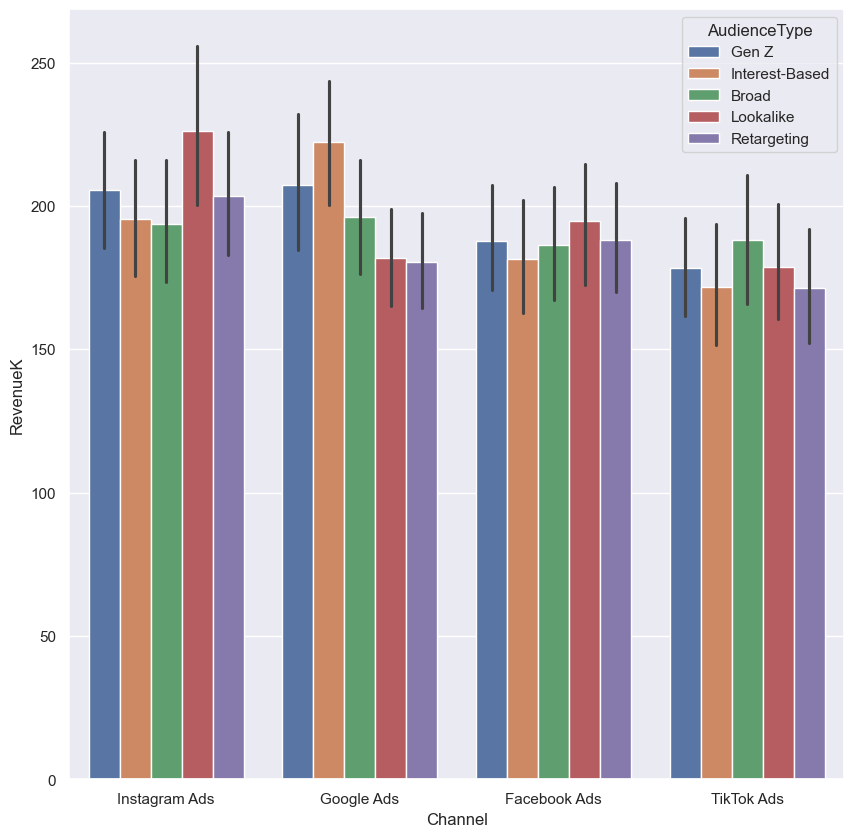

In [35]:
plt.figure(figsize=(10,10))
sns.barplot(x='Channel', y='RevenueK', hue='AudienceType', data=campaign)
plt.show()

- Lookalike targeting strategy delivers the highest revenue results on Instagram Ads compared to other platforms.
- For Interest-Based and Gen Z targeting, Google Ads performed the most competitively, making it ideal for capturing audiences with specific purchase intent.

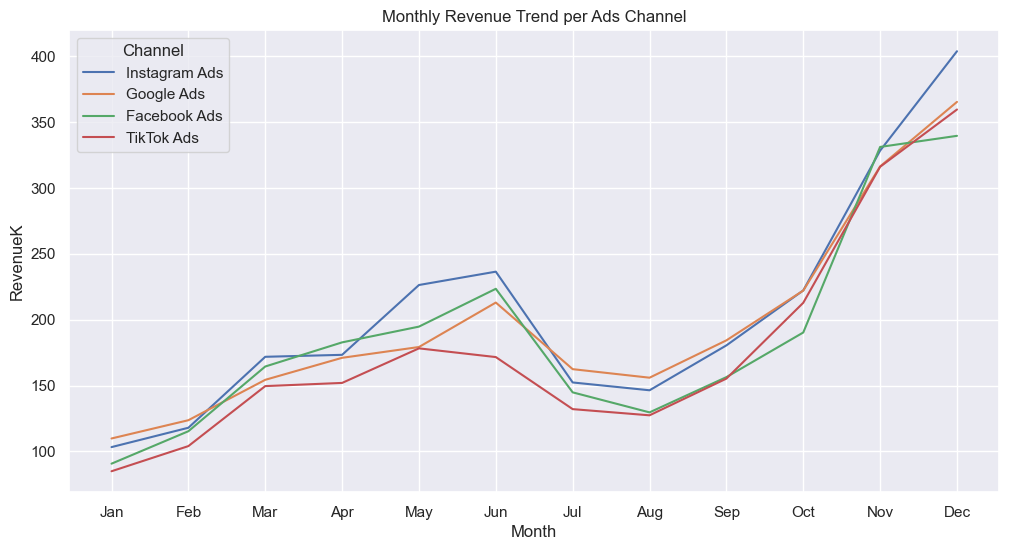

In [36]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Month', y='RevenueK', hue='Channel', data=campaign, errorbar=None)
plt.title('Monthly Revenue Trend per Ads Channel')
plt.show()

- Instagram Ads showed the most explosive performance at the end of the year
- All advertising channels have a similar trend pattern, namely experiencing a gradual increase from January to June, then experiencing a decline in July and increasing again in the last quarter.

### Business Recommendation

- Reviewing 105 inactive channels. If they have potential, a minimum budget allocation is required to avoid wasted revenue opportunities.
- Given the strong End-of-Year Effect, fourth-quarter promotional strategies should be prepared early with bolder budget scalability on Instagram and Google.
- Evaluate TikTok Ads performance thoroughly. If the downward trend continues, consider reallocating the remaining budget to Google Ads (Interest targeting) or Instagram (Lookalike audiences).
- We need to reconsider the efficiency of our spend on TikTok Ads, we can focus on using only three types of channels